In [1]:
import torch
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import json
import re

MODEL_DIR = "checkpoints"

In [2]:
device = torch.device('cuda:0')

In [3]:
with open(os.path.join(MODEL_DIR, "config.json"), "r") as f:
    cfg = json.load(f)

In [4]:
# SSL TRAINING PARAMETERS

# --- Base params (from config) ---
# Image
D_IMAGE    = cfg["data"]["d_image"]
N_CHANNELS = cfg["data"]["n_channels"]
PATCH_SIZE = cfg["data"]["patch_size"]
# Encoder
D_ENC            = cfg["model"]["d_enc"]
N_HEADS_ENC      = cfg["model"]["n_heads_enc"]
N_ENCODER_BLOCKS = cfg["model"]["n_encoder_blocks"]
MLP_RATIO        = cfg["model"]["mlp_ratio"]
# Decoder
D_DEC            = cfg["model"]["d_dec"]
N_HEADS_DEC      = cfg["model"]["n_heads_dec"]
N_DECODER_BLOCKS = cfg["model"]["n_decoder_blocks"]
# Training
WORLD_SIZE            = cfg["metadata"]["world_size"]
LR                    = cfg["metadata"]["lr"]
BATCH_SIZE            = cfg["metadata"]["batch_size"]
WEIGHT_DECAY          = cfg["metadata"]["weight_decay"]
MOMENTUM              = cfg["metadata"]["momentum"]            # [0.9, 0.95]
WARMUP_EPOCHS         = cfg["metadata"]["warmup_epochs"]
N_EPOCHS              = cfg["metadata"]["n_epochs"]
PERCENT_UNMASKED      = cfg["metadata"]["percent_unmasked"]
USE_AUTOCAST          = cfg["metadata"]["use_autocast"]
USE_GRAD_ACCUMULATION = cfg["metadata"]["use_grad_accumulation"]
MICRO_BATCH_SIZE      = cfg["metadata"]["micro_batch_size"]
LOAD_MODEL            = cfg["metadata"]["load_model"]
R_MODEL_PATH          = cfg["metadata"]["r_model_path"]
CHECKPOINT_EVERY      = cfg["metadata"]["checkpoint_every"] # epochs between compressed checkpoints
PLOT_EVERY            = cfg["metadata"]["plot_every"] # epochs between loss-curve refreshes
OUTPUT_DIR            = cfg["metadata"]["output_dir"]
CHECKPOINT_DIR        = cfg["metadata"]["checkpoint_dir"]
USE_HF                = cfg["metadata"]["use_hf"]
HF_REPO               = cfg["metadata"]["hf_repo"]
HF_OUTPUT_DIR         = cfg["metadata"]["hf_output_dir"]
# --- Derived params (computed) ---
D_PATCH   = (PATCH_SIZE ** 2) * N_CHANNELS 
N_PATCHES = (D_IMAGE ** 2) // (PATCH_SIZE ** 2)
N_ROWS    = D_IMAGE // PATCH_SIZE
D_ENC_MLP = int(MLP_RATIO * D_ENC)
D_DEC_MLP = int(MLP_RATIO * D_DEC)

In [14]:
# FINE-TUNING AND VISUALIZATION PARAMETERS
micro_batch_size = 128
NUM_IMAGES = 4              # number of test images = number of columns
SEED       = 5             # controls (a) which test images, (b) the SHARED mask
GRAY       = 0.5            # display value for masked-out pixels in the "masked" row
OUT_PATH   = "mae_reconstructions.png"
 
# Dataset normalization used in your test_transform (needed to map back to pixels)
NORM_MEAN = [0.4467, 0.4398, 0.4066]
NORM_STD  = [0.2604, 0.2566, 0.2713]
 
device = torch.device("cpu")   # CPU works for few image displays

In [6]:
# Transforms
# train_transform = transforms.Compose([
#     transforms.RandomResizedCrop(D_IMAGE, scale=(0.5, 1.0)),
#     transforms.RandomHorizontalFlip(),
#     transforms.ToTensor(),
#     transforms.Normalize((0.4467, 0.4398, 0.4066), (0.2604, 0.2566, 0.2713))
# ])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4467, 0.4398, 0.4066), (0.2604, 0.2566, 0.2713))
])
# Load datasets
# supervised_trainset = torchvision.datasets.STL10(
#     root='./data', split='train', download=False, transform=train_transform
# )
testset = torchvision.datasets.STL10(
    root='./data', split='test', download=False, transform=test_transform
)
# unlabeled_set = torchvision.datasets.STL10(
#     root='./data', split='unlabeled', download=False, transform=train_transform
# )

In [7]:
# supervised_trainloader = DataLoader(
#     supervised_trainset, batch_size=micro_batch_size, shuffle=True, num_workers=2
# )
testloader = DataLoader(
    testset, batch_size=micro_batch_size, shuffle=False, num_workers=2
)

In [8]:
from model import get_pos_embeddings, Net
pos_embeddings_enc = get_pos_embeddings(D_ENC, N_PATCHES, N_ROWS)
pos_embeddings_dec = get_pos_embeddings(D_DEC, N_PATCHES, N_ROWS)

model = Net(
    n_encoder_blocks=N_ENCODER_BLOCKS,
    n_decoder_blocks=N_DECODER_BLOCKS,
    d_image=D_IMAGE,
    patch_size=PATCH_SIZE,
    d_patch=D_PATCH,
    n_patches=N_PATCHES,
    n_rows=N_ROWS,
    d_enc=D_ENC,
    d_enc_mlp=D_ENC_MLP,
    d_dec=D_DEC,
    d_dec_mlp=D_DEC_MLP,
    n_heads_enc=N_HEADS_ENC,
    n_heads_dec=N_HEADS_DEC,
    pos_embeddings_enc=pos_embeddings_enc,
    pos_embeddings_dec=pos_embeddings_dec,
    percent_unmasked=PERCENT_UNMASKED)

In [9]:
CHECKPOINTS = [
    "checkpoint_epoch_100.pt",
    "checkpoint_epoch_300.pt",
    "checkpoint_epoch_760.pt",
]

In [10]:
def unpatchify(patches, n_rows, P, C):
    """Inverse of model.encode's patchify. Verified to round-trip exactly.
 
    patchify: x.unfold(2,P,P).unfold(3,P,P) -> permute(0,2,3,1,4,5) -> view(B,SEQ,d_patch)
    so a patch's d_patch vector is laid out as (C, P_h, P_w) and patch index = row*n_rows+col.
    """
    B = patches.shape[0]
    x = patches.reshape(B, n_rows, n_rows, C, P, P)   # (B,row,col,C,p_h,p_w)
    x = x.permute(0, 3, 1, 4, 2, 5).contiguous()      # (B,C,row,p_h,col,p_w)
    x = x.reshape(B, C, n_rows * P, n_rows * P)        # (B,C,H,W)
    return x
 
 
def to_display(img_bchw):
    """normalized-image space -> [0,1] HWC numpy, undoing dataset Normalize."""
    mean = torch.tensor(NORM_MEAN).view(1, 3, 1, 1)
    std = torch.tensor(NORM_STD).view(1, 3, 1, 1)
    img = (img_bchw * std + mean).clamp(0, 1)
    return img.permute(0, 2, 3, 1).cpu().numpy()

Using test indices: [5411, 2443, 5943, 1337]
Saved figure to mae_reconstructions.png


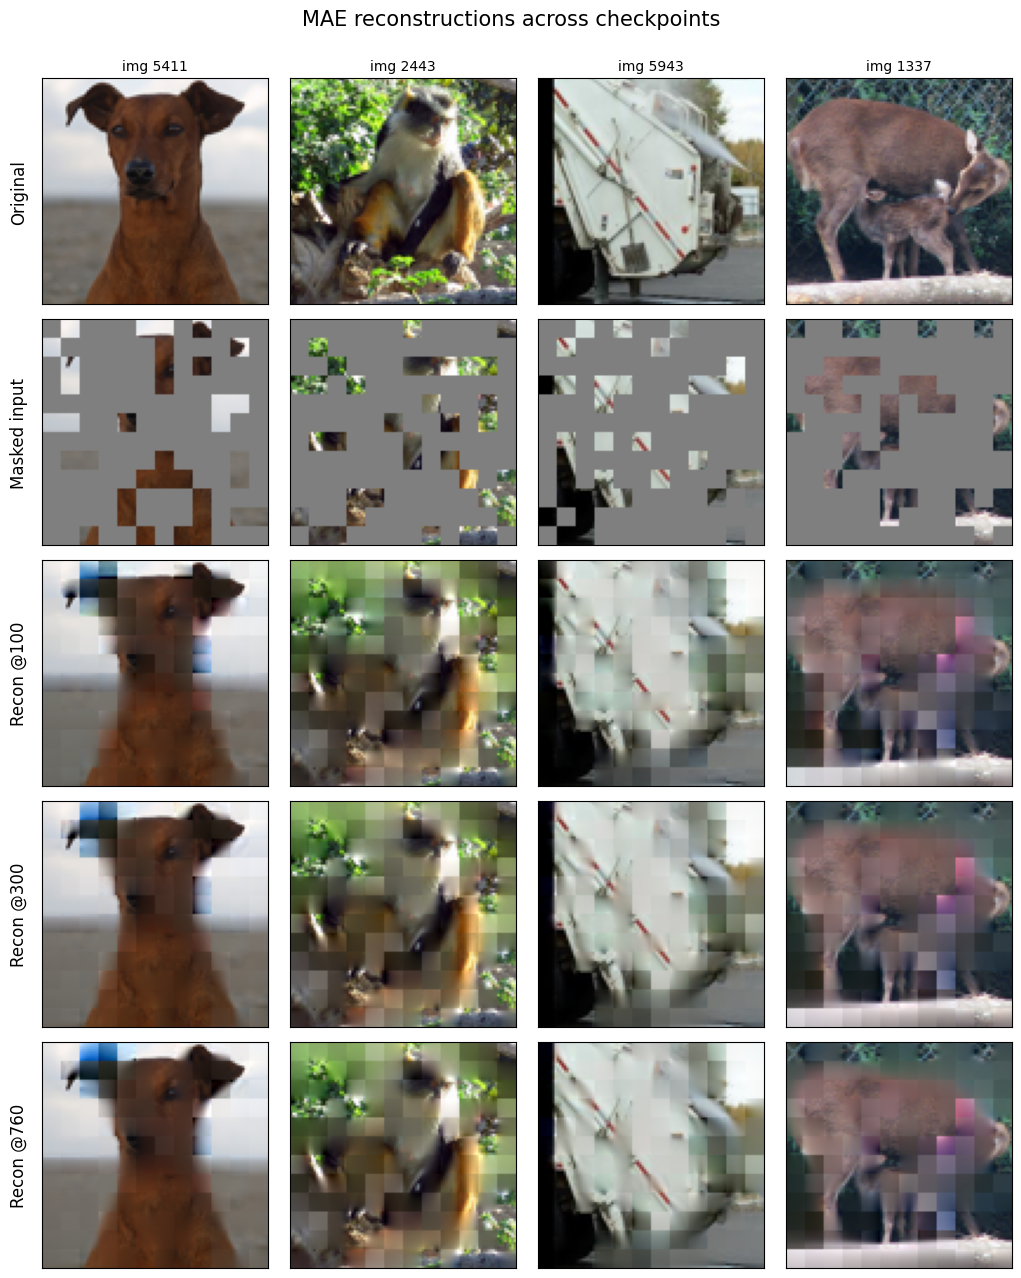

In [15]:
paths = [os.path.join(MODEL_DIR, c) for c in CHECKPOINTS]

# --- pick the same NUM_IMAGES test images every run, build one batch ---
g = torch.Generator().manual_seed(SEED)
idxs = torch.randperm(len(testset), generator=g)[:NUM_IMAGES].tolist()
print("Using test indices:", idxs)
batch = torch.stack([testset[i][0] for i in idxs])  # (N,C,H,W), normalized

# --- run each checkpoint with an IDENTICAL mask ---
# The only randomness in forward() is `noise = torch.rand(B, SEQ)`. Re-seeding
# immediately before each forward makes every checkpoint see the same mask,
# which is essential for a fair side-by-side comparison.
recon_displays = []          # one (N,H,W,C) array per checkpoint
shared_ids_masked = None     # the common mask, captured once
truth_patches_ref = None

for path in paths:
    sd = torch.load(path, map_location="cpu", weights_only=True)["model_state_dict"]
    model.load_state_dict(sd)
    model.to(device)
    model.eval()
    torch.manual_seed(SEED)  # <-- makes the mask identical across checkpoints
    with torch.no_grad():
        y_patches, y_true_patches, ids_masked = model(batch)

    if shared_ids_masked is None:
        shared_ids_masked = ids_masked
        truth_patches_ref = y_true_patches
    else:
        # sanity: confirm the mask really is shared
        assert torch.equal(ids_masked, shared_ids_masked), "masks differ across checkpoints!"

    # per-patch denormalization, inverting the exact transform used in the loss:
    #   target = (true - mean) / sqrt(var + 1e-6),  var is unbiased (torch default)
    mean_t = y_true_patches.mean(dim=-1, keepdim=True)
    var_t = y_true_patches.var(dim=-1, keepdim=True)
    pred_denorm = y_patches * (var_t + 1e-6).sqrt() + mean_t

    # build (B, N_PATCHES, 1) mask: 1 where masked
    mask1 = torch.zeros(batch.shape[0], N_PATCHES, 1)
    mask1.scatter_(1, ids_masked.unsqueeze(-1), 1.0)

    # paste: visible patches = ground truth, masked patches = model prediction
    recon_patches = torch.where(mask1.bool(), pred_denorm, y_true_patches)
    recon_img = unpatchify(recon_patches, N_ROWS, PATCH_SIZE, N_CHANNELS)
    recon_displays.append(to_display(recon_img))

# --- row 0: original, rebuilt from y_true_patches (verifies the pixel round-trip) ---
orig_img = unpatchify(truth_patches_ref, N_ROWS, PATCH_SIZE, N_CHANNELS)
orig_disp = to_display(orig_img)

# --- row 1: masked input ---
mask1 = torch.zeros(batch.shape[0], N_PATCHES, 1)
mask1.scatter_(1, shared_ids_masked.unsqueeze(-1), 1.0)
mask_img = unpatchify(mask1.expand(-1, -1, D_PATCH), N_ROWS, PATCH_SIZE, N_CHANNELS)[:, 0]  # (B,H,W), one channel
mask_hw = mask_img.unsqueeze(-1).cpu().numpy()                            # (B,H,W,1)
masked_disp = orig_disp * (1 - mask_hw) + GRAY * mask_hw

# --- assemble the grid ---
epochs = []
for c in CHECKPOINTS:
    m = re.search(r"(\d+)", os.path.basename(c))
    epochs.append(m.group(1) if m else "?")
row_labels = ["Original", "Masked input"] + [f"Recon @{e}" for e in epochs]
rows = [orig_disp, masked_disp] + recon_displays

n_plot_rows = len(CHECKPOINTS) + 2
n = NUM_IMAGES
fig, axes = plt.subplots(n_plot_rows, n, figsize=(n * 2.6, n_plot_rows * 2.6))
if n == 1:
    axes = axes.reshape(n_plot_rows, 1)

for r in range(n_plot_rows):
    for col in range(n):
        ax = axes[r, col]
        ax.imshow(rows[r][col])
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(row_labels[r], fontsize=12, rotation=90, labelpad=10)
        if r == 0:
            ax.set_title(f"img {idxs[col]}", fontsize=10)

fig.suptitle("MAE reconstructions across checkpoints", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.savefig(OUT_PATH, dpi=200, bbox_inches="tight")
print(f"Saved figure to {OUT_PATH}")